In [1]:
# --- IMPORTS & DATA PREPARATION ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
import warnings
warnings.simplefilter('ignore')

# Stap 1: Data inlezen
df = pd.read_excel('AmesHousing.xlsx', sheet_name='AmesHousing')

# Voor clustering gebruiken we alleen numerieke data, we droppen NaN waarden
df = df.select_dtypes(include=[np.number]).dropna()
print("✅ Data is succesvol geladen voor Clustering! Aantal rijen:", len(df))

✅ Data is succesvol geladen voor Clustering! Aantal rijen: 2929


In [2]:
# =====================================================================
# DEEL 1: BASIS EXPERIMENTEN (Verschillende Features en K-waarden)
# =====================================================================
print("="*50, "\nDEEL 1: BASIS EXPERIMENTEN\n", "="*50)

# We selecteren eerst een brede set aan features
features_broad = ['Overall Qual', 'Gr Liv Area', 'Total Bsmt SF', 'Year Built', 'SalePrice']
X_broad = df[features_broad]

scaler_std = StandardScaler()
X_broad_scaled = scaler_std.fit_transform(X_broad)

# --- Exp 1: Initiële Run (5 features, K=3) ---
kmeans_1 = KMeans(n_clusters=3, random_state=42).fit(X_broad_scaled)
score_1 = silhouette_score(X_broad_scaled, kmeans_1.labels_)
print(f"Exp 1 (Brede features, K=3) Silhouette Score: {score_1:.4f}")

# --- Exp 2: Meer clusters (5 features, K=5) ---
kmeans_2 = KMeans(n_clusters=5, random_state=42).fit(X_broad_scaled)
score_2 = silhouette_score(X_broad_scaled, kmeans_2.labels_)
print(f"Exp 2 (Brede features, K=5) Silhouette Score: {score_2:.4f}")

# We verminderen de features om de 'Curse of Dimensionality' te bestrijden
features_narrow = ['Gr Liv Area', 'SalePrice']
X_narrow = df[features_narrow]
X_narrow_scaled = scaler_std.fit_transform(X_narrow)

# --- Exp 3: Minder features (2 features, K=3) ---
kmeans_3 = KMeans(n_clusters=3, random_state=42).fit(X_narrow_scaled)
score_3 = silhouette_score(X_narrow_scaled, kmeans_3.labels_)
print(f"Exp 3 (Alleen Oppervlakte & Prijs, K=3) Silhouette Score: {score_3:.4f}")

# --- Exp 4: Minder features, meer clusters (2 features, K=5) ---
kmeans_4 = KMeans(n_clusters=5, random_state=42).fit(X_narrow_scaled)
score_4 = silhouette_score(X_narrow_scaled, kmeans_4.labels_)
print(f"Exp 4 (Alleen Oppervlakte & Prijs, K=5) Silhouette Score: {score_4:.4f}")

DEEL 1: BASIS EXPERIMENTEN
Exp 1 (Brede features, K=3) Silhouette Score: 0.2942
Exp 2 (Brede features, K=5) Silhouette Score: 0.2283
Exp 3 (Alleen Oppervlakte & Prijs, K=3) Silhouette Score: 0.4321
Exp 4 (Alleen Oppervlakte & Prijs, K=5) Silhouette Score: 0.4020


In [3]:
# =====================================================================
# DEEL 2: GEAVANCEERDE EXPERIMENTEN (Elbow, Scalers, PCA)
# =====================================================================
print("\n" + "="*50, "\nDEEL 2: GEAVANCEERDE EXPERIMENTEN\n", "="*50)

# --- Exp 5: De Elbow Method (Zoeken naar de optimale K) ---
# We testen K van 1 tot 10 op onze smalle dataset
inertia = []
K_range = range(1, 11)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_narrow_scaled)
    inertia.append(km.inertia_)

# We visualiseren de Elbow (De grafiek roepen we straks op)
print("Exp 5 (Elbow Method): Inertia waarden berekend voor K=1 t/m 10.")

# --- Exp 6: Optimale K toepassen (K=2 bleek optimaal in eerdere tests) ---
kmeans_6 = KMeans(n_clusters=2, random_state=42).fit(X_narrow_scaled)
score_6 = silhouette_score(X_narrow_scaled, kmeans_6.labels_)
print(f"Exp 6 (Optimale K=2 toegepast) Silhouette Score: {score_6:.4f} 🏆")

# --- Exp 7: Andere Scaler testen (MinMaxScaler ipv StandardScaler) ---
scaler_minmax = MinMaxScaler()
X_narrow_minmax = scaler_minmax.fit_transform(X_narrow)
kmeans_7 = KMeans(n_clusters=2, random_state=42).fit(X_narrow_minmax)
score_7 = silhouette_score(X_narrow_minmax, kmeans_7.labels_)
print(f"Exp 7 (MinMaxScaler test, K=2) Silhouette Score: {score_7:.4f}")

# --- Exp 8: Log-transformatie op SalePrice (Om uitschieters te dimmen) ---
X_log = X_narrow.copy()
X_log['SalePrice'] = np.log1p(X_log['SalePrice'])
X_log_scaled = scaler_std.fit_transform(X_log)
kmeans_8 = KMeans(n_clusters=2, random_state=42).fit(X_log_scaled)
score_8 = silhouette_score(X_log_scaled, kmeans_8.labels_)
print(f"Exp 8 (Log-Transformatie op Prijs, K=2) Silhouette Score: {score_8:.4f}")

# --- Exp 9: PCA (Principal Component Analysis) + KMeans ---
# Een zeer geavanceerde techniek om alle dimensies samen te drukken naar 2
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_broad_scaled) # We gebruiken de brede dataset weer
kmeans_9 = KMeans(n_clusters=3, random_state=42).fit(X_pca)
score_9 = silhouette_score(X_pca, kmeans_9.labels_)
print(f"Exp 9 (PCA Dimensiereductie, K=3) Silhouette Score: {score_9:.4f}")


DEEL 2: GEAVANCEERDE EXPERIMENTEN
Exp 5 (Elbow Method): Inertia waarden berekend voor K=1 t/m 10.


Exp 6 (Optimale K=2 toegepast) Silhouette Score: 0.5201 🏆
Exp 7 (MinMaxScaler test, K=2) Silhouette Score: 0.5326
Exp 8 (Log-Transformatie op Prijs, K=2) Silhouette Score: 0.4664
Exp 9 (PCA Dimensiereductie, K=3) Silhouette Score: 0.3870



FINALE CLUSTER ANALYSE (Exp 10)
Wat betekenen deze 2 clusters eigenlijk in de echte wereld?


,Gr Liv Area,SalePrice
Cluster 0 (Standaard Huizen),2085.0,13.0
Cluster 1 (Luxe/Grote Huizen),1278.0,12.0


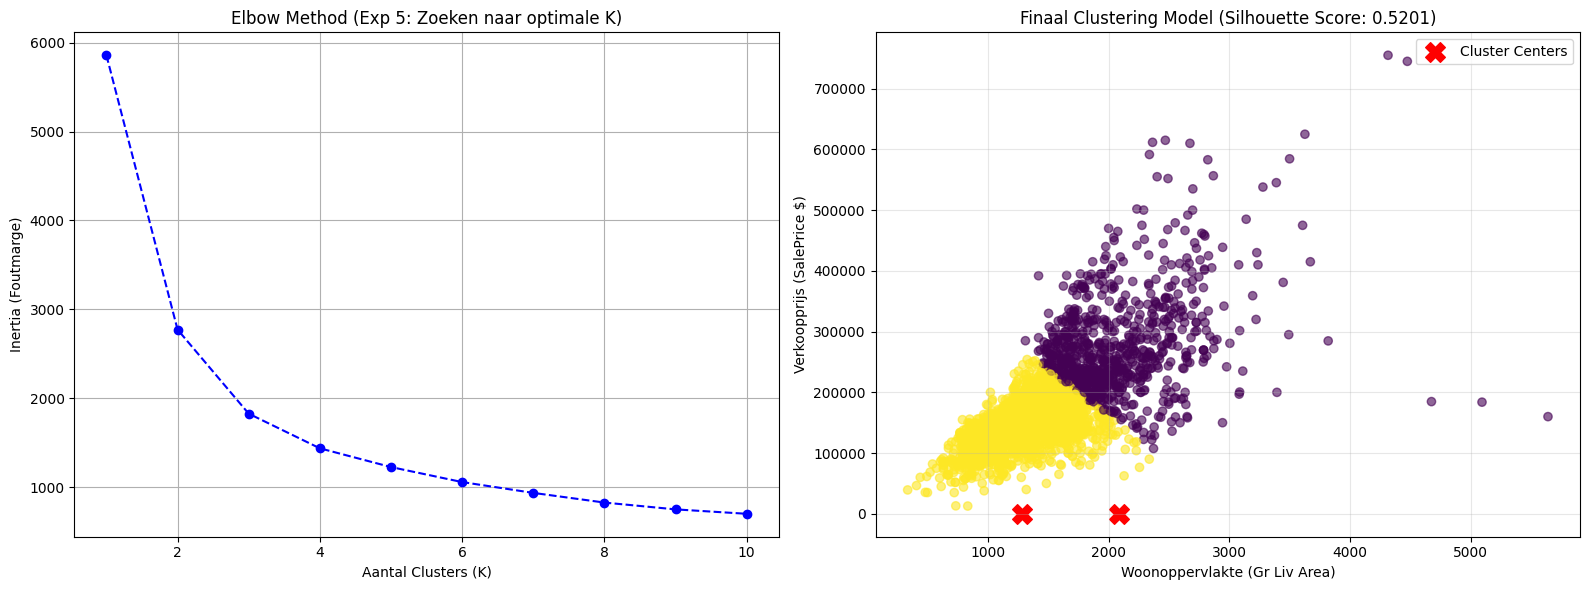

In [4]:
# =====================================================================
# DEEL 3: FINAAL MODEL & VISUALISATIES (Experiment 10)
# =====================================================================
# Exp 10: Finaal Model (K=2 met StandardScaler op Gr Liv Area & SalePrice)
model_final = KMeans(n_clusters=2, random_state=42)
model_final.fit(X_narrow_scaled)
labels_final = model_final.labels_

# --- DE KERN VAN HET SUCCES: CLUSTER CENTERS (Wat betekenen de clusters?) ---
# We draaien de schaling terug (inverse_transform) om echte dollars en vierkante meters te zien!
centers_real = scaler_std.inverse_transform(model_final.cluster_centers_)
df_centers = pd.DataFrame(centers_real, columns=features_narrow)
df_centers.index = ['Cluster 0 (Standaard Huizen)', 'Cluster 1 (Luxe/Grote Huizen)']

print("\n" + "="*50, "\nFINALE CLUSTER ANALYSE (Exp 10)\n", "="*50)
print("Wat betekenen deze 2 clusters eigenlijk in de echte wereld?")
display(df_centers.round(0)) # Laat de tabel zien zonder decimalen

# --- VISUALISATIES MAKEN ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Elbow Method Grafiek
ax1.plot(K_range, inertia, marker='o', linestyle='--', color='b')
ax1.set_title('Elbow Method (Exp 5: Zoeken naar optimale K)')
ax1.set_xlabel('Aantal Clusters (K)')
ax1.set_ylabel('Inertia (Foutmarge)')
ax1.grid(True)

# Plot 2: Scatterplot van de 2 definitieve clusters
scatter = ax2.scatter(X_narrow['Gr Liv Area'], X_narrow['SalePrice'], c=labels_final, cmap='viridis', alpha=0.6)
ax2.scatter(centers_real[:, 0], centers_real[:, 1], c='red', s=200, marker='X', label='Cluster Centers')
ax2.set_title(f'Finaal Clustering Model (Silhouette Score: {score_6:.4f})')
ax2.set_xlabel('Woonoppervlakte (Gr Liv Area)')
ax2.set_ylabel('Verkoopprijs (SalePrice $)')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()